# §6 Device Productivity — the chip as the unit of analysis

Answers the draft's questions directly: how fast are new chips taken up, how
long do they stay productive, and how many papers / citations does each chip
support?

* **6.1 Paper support** — papers per device model. A paper counts once for
  every model it reports, so a paper naming k models supports all k: credit is a
  count of supporting papers, never a 1/k split.
* **6.2 Productive half-life** — years from a model's peak share of
  accelerator-using papers until it sustainedly falls below half of that peak,
  with bootstrap CIs and right-censoring. The 3–5 year grant cycle is the
  policy-relevant benchmark for buy-vs-rent decisions, discussed in the text.
* **6.3 Adoption lag** — release date → first mention → 10th/100th paper, by
  hardware generation: is diffusion into science speeding up?
* **6.4 Citation support** — 3-year citations (`i_3`) per model, on the same
  counting rule. The shorter citation window admits more recent papers, and
  therefore more recent accelerators.

> Descriptive attribution, not causal: a paper crediting a chip is not evidence
> the chip caused the result. Because each supporting paper is counted once per
> model it names, per-model counts sum to more than the number of papers — that
> is the intended semantics, not double counting to be corrected away.

Inputs: `python -m accelscan.denominator` and `python -m accelscan.compute`.

In [14]:
%matplotlib inline
import matplotlib.colors as mcolors
import matplotlib.pyplot as plt
import numpy as np
import polars as pl
from accelscan.config import BUCKET, OUT_PREFIX
from accelscan.normalize import canonicalize_column
from accelscan.registry import load_registry
from accelscan.s3 import mentions_glob, storage_options
from accelscan.plotting import setup_figures, spread_labels

# integer year ticks + every figure exported to output/analysis/productivity/
setup_figures('productivity')

## Knobs

In [15]:
MODEL_TAG, PROMPT_VERSION = 'qwen3-14b', 'p1'
YEAR_MIN, YEAR_MAX = 2005, 2025
USED_ONLY = True            # restrict to used-in-this-work mentions
MIN_PAPERS_MODEL = 100      # eligibility for lifecycle estimates (plan: 100; robustness 50/250)
SMOOTH = 3                  # years in the moving average for half-life
CITE_WINDOW = 3             # years of forward citations (i_3); i_1/i_5/i_10 also available
CITE_CUTOFF = 2023          # last year with a complete CITE_WINDOW in the outcomes build
BOOTSTRAP = 200
LOCAL_ANALYTIC = None

PAL = ['#0072B2', '#D55E00', '#009E73', '#CC79A7', '#E69F00', '#56B4E9', '#999999',
       '#000000', '#984EA3', '#44AA99']
reg = load_registry(); so = storage_options()

## Load paper×model observations + outcomes

In [16]:
base = (LOCAL_ANALYTIC or
        f's3://{BUCKET}/{OUT_PREFIX}/analytic/{reg.version}/{PROMPT_VERSION}/{MODEL_TAG}')
rd = (lambda n: pl.read_parquet(f'{base}/{n}.parquet')) if LOCAL_ANALYTIC else \
     (lambda n: pl.read_parquet(f'{base}/{n}.parquet', storage_options=so))
den = rd('denominator').select('corpusid', 'year', 'field')
cit = rd('citations')

m = (pl.scan_parquet(mentions_glob(MODEL_TAG, PROMPT_VERSION), storage_options=so)
     .filter(pl.col('status') == 'ok')
     .select('corpusid', 'model_normalized', 'manufacturer', 'usage_context')
     .collect())
if USED_ONLY:
    m = m.filter(pl.col('usage_context') == 'used-in-this-work')
m = canonicalize_column(m, reg).filter(pl.col('canonical_kind') == 'model')

meta = pl.DataFrame(
    [{'canonical_model': x.id, 'display': x.display, 'manufacturer_reg': x.manufacturer,
      'segment': x.segment, 'architecture': x.architecture,
      'release_year': int(x.release[:4]) if x.release else None,
      'release_ym': x.release, 'fp32_gflops': x.fp32_gflops}
     for x in reg.models.values() if x.kind == 'model'],
    schema={'canonical_model': pl.Utf8, 'display': pl.Utf8, 'manufacturer_reg': pl.Utf8,
            'segment': pl.Utf8, 'architecture': pl.Utf8, 'release_year': pl.Int32,
            'release_ym': pl.Utf8, 'fp32_gflops': pl.Float64})

# one row per (paper, model): a paper supports every model it reports, so these
# rows ARE the credit units (k rows for a paper naming k models)
pm = (m.select('corpusid', 'canonical_model').unique()
      .join(den, on='corpusid', how='inner')
      .filter(pl.col('year').is_between(YEAR_MIN, YEAR_MAX)))
pm = (pm.join(pm.group_by('corpusid').agg(n_models=pl.len()), on='corpusid')
      .join(meta, on='canonical_model', how='left')
      .join(cit.select('corpusid', citations=f'i_{CITE_WINDOW}',
                       has_outcomes='has_outcomes'), on='corpusid', how='left'))
# i_k is populated even where k years have not elapsed, so completeness has to come
# from the publication year, not from null-ness: i_3 is complete for papers <= 2022
# under the same outcomes build that made i_5 complete only through 2020.
pm = pm.with_columns(cite_window_complete=pl.col('year') <= CITE_CUTOFF)
print(f'{pm.height:,} paper-model observations | {pm.n_unique("corpusid"):,} papers '
      f'| {pm.n_unique("canonical_model"):,} models')

197,376 paper-model observations | 179,975 papers | 534 models


## 6.1 Paper support per device model

**Left — volume:** total papers supported, the raw count of supporting papers.
Structurally biased toward chips that have been available longer.

**Right — rate:** papers supported per year of observable life, i.e. total support
divided by the years from release to the end of the window
(`YEAR_MAX - max(release_year, YEAR_MIN) + 1`). This is the age-normalised measure:
it answers "while this chip existed, how much science did it carry per year?", which
is what makes a 2023 part comparable to a 2014 one.

The two panels are ranked **independently**, so they surface different chips on
purpose — a long-lived workhorse can top the volume panel while a recent part tops
the rate panel. Exposure is truncated on both sides: a chip released before
`YEAR_MIN` gets credit only from `YEAR_MIN`, and every chip's window ends at
`YEAR_MAX`, so the newest parts' rates rest on one or two years and are the least
stable. Models with no registry release date are excluded from the rate panel only.


104 models meet the >=100-paper eligibility bar


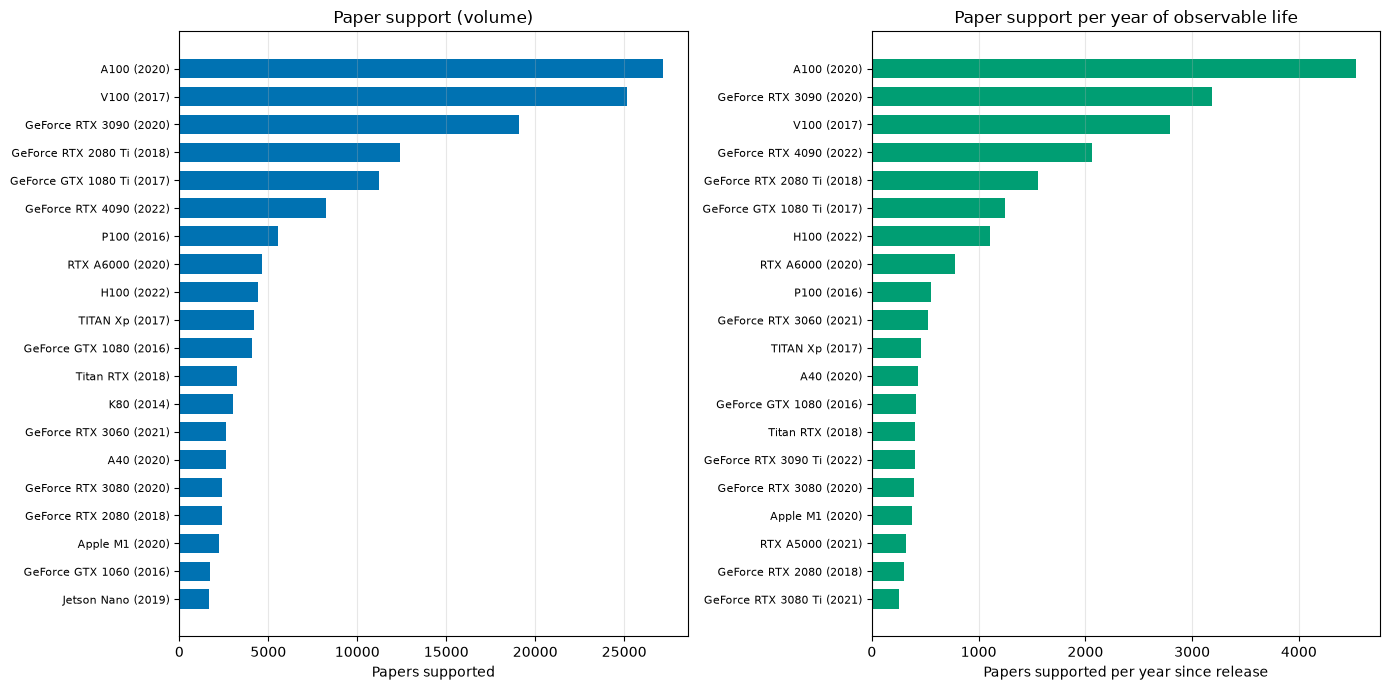

shape: (25, 6)
┌──────────────────────────┬──────────────┬────────┬────────────────┬─────────────────┬────────────┐
│ display                  ┆ release_year ┆ papers ┆ exposure_years ┆ papers_per_year ┆ first_year │
│ ---                      ┆ ---          ┆ ---    ┆ ---            ┆ ---             ┆ ---        │
│ str                      ┆ i32          ┆ u32    ┆ i32            ┆ f64             ┆ i64        │
╞══════════════════════════╪══════════════╪════════╪════════════════╪═════════════════╪════════════╡
│ NVIDIA A100              ┆ 2020         ┆ 27198  ┆ 6              ┆ 4533.0          ┆ 2018       │
│ NVIDIA GeForce RTX 3090  ┆ 2020         ┆ 19109  ┆ 6              ┆ 3184.8          ┆ 2019       │
│ NVIDIA V100              ┆ 2017         ┆ 25172  ┆ 9              ┆ 2796.9          ┆ 2014       │
│ NVIDIA GeForce RTX 4090  ┆ 2022         ┆ 8256   ┆ 4              ┆ 2064.0          ┆ 2020       │
│ NVIDIA GeForce RTX 2080  ┆ 2018         ┆ 12419  ┆ 8              ┆ 1552.4

In [17]:
sup = (pm.group_by('canonical_model', 'display', 'release_year', 'segment', 'architecture')
       .agg(papers=pl.len(),
            first_year=pl.col('year').min(), peak_year_raw=pl.col('year').mode().first())
       .sort('papers', descending=True))
# Observable lifetime: release -> end of window, clipped to the window's start so
# pre-YEAR_MIN chips are not credited with years the corpus does not cover.
# max_horizontal ignores nulls, so an unknown release date would silently inherit
# YEAR_MIN and get a full-window exposure: keep it null instead of inventing a rate
sup = sup.with_columns(
    exposure_years=pl.when(pl.col('release_year').is_not_null())
    .then((YEAR_MAX - pl.max_horizontal('release_year', pl.lit(YEAR_MIN)) + 1).clip(1, None))
    .otherwise(None).cast(pl.Int32))
sup = sup.with_columns(papers_per_year=pl.col('papers') / pl.col('exposure_years'))
elig = sup.filter(pl.col('papers') >= MIN_PAPERS_MODEL)
print(f'{elig.height} models meet the >={MIN_PAPERS_MODEL}-paper eligibility bar')

def barh_panel(ax, d, col, xlabel, title, color):
    y = np.arange(d.height)
    ax.barh(y, d[col], 0.7, color=color)
    ax.set_yticks(y)
    ax.set_yticklabels([f"{s.replace('NVIDIA ', '')} ({r})" for s, r in
                        zip(d['display'], d['release_year'])], fontsize=8)
    ax.invert_yaxis(); ax.set(xlabel=xlabel, title=title)
    ax.grid(alpha=0.3, axis='x')

top = elig.head(20)
rate = (elig.filter(pl.col('release_year').is_not_null())
        .sort('papers_per_year', descending=True).head(20))
fig, axes = plt.subplots(1, 2, figsize=(14, 7))
# ranked independently: volume favours long-available chips, the rate is age-normalised
barh_panel(axes[0], top, 'papers', 'Papers supported',
           'Paper support (volume)', '#0072B2')
barh_panel(axes[1], rate, 'papers_per_year', 'Papers supported per year since release',
           'Paper support per year of observable life', '#009E73')
plt.tight_layout(); plt.show()
with pl.Config(tbl_rows=25, fmt_str_lengths=40):
    print(elig.sort('papers_per_year', descending=True, nulls_last=True)
          .select('display', 'release_year', 'papers', 'exposure_years',
                  pl.col('papers_per_year').round(1), 'first_year').head(25))

### 6.1b Paper support over a device's life

Where 6.1 gives each chip a single number, this shows the shape of its support over
time: papers supported per year on a log axis, plotted against **years since
release** so the lifecycles align — a 2014 chip and a 2023 chip become directly
comparable instead of sitting in different parts of a calendar axis.

Log scale because support spans orders of magnitude across these models, and because
on a log axis equal *slopes* mean equal *growth rates*: the ramp-up and decay phases
can be compared between chips even when their levels differ 100-fold. Levels are
readable too, unlike the indexed version this replaced — the vertical gap between two
lines is the ratio of papers they carry.

Lines are ordered by release year and **dashed for the earlier half of the models,
solid for the later half**, so "do newer chips ramp faster and fall off sooner?" is a
comparison of dashed against solid. Color is unique within each style group, so a
(color, style) pair identifies a model. Years with zero supporting papers are absent
rather than plotted at zero, which a log axis cannot show.


/tmp/ipykernel_1498774/4046296967.py:4: DeprecationWarning: `is_in` with a collection of the same datatype is ambiguous and deprecated.
Please use `implode` to return to previous behavior.

See https://github.com/pola-rs/polars/issues/22149 for more information.
  ts = (pm.filter(pl.col('canonical_model').is_in(tm['canonical_model']))


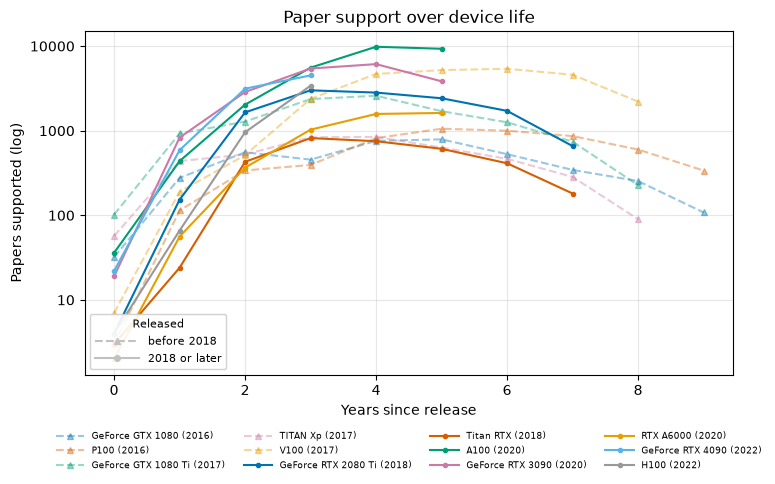

shape: (12, 6)
┌───────────────────┬──────────────┬─────────────┬──────────────────┬─────────────┬────────────────┐
│ display           ┆ release_year ┆ peak_papers ┆ peak_since_relea ┆ last_papers ┆ years_observed │
│ ---               ┆ ---          ┆ ---         ┆ se               ┆ ---         ┆ ---            │
│ str               ┆ i32          ┆ u32         ┆ ---              ┆ u32         ┆ u32            │
│                   ┆              ┆             ┆ i64              ┆             ┆                │
╞═══════════════════╪══════════════╪═════════════╪══════════════════╪═════════════╪════════════════╡
│ NVIDIA GeForce    ┆ 2016         ┆ 790         ┆ 5                ┆ 108         ┆ 10             │
│ GTX 1080          ┆              ┆             ┆                  ┆             ┆                │
│ NVIDIA P100       ┆ 2016         ┆ 1055        ┆ 5                ┆ 338         ┆ 10             │
│ NVIDIA GeForce    ┆ 2017         ┆ 2592        ┆ 4                ┆ 227   

In [18]:
TOP_N_CHANGE = 12

tm = elig.sort('papers', descending=True).head(TOP_N_CHANGE)
ts = (pm.filter(pl.col('canonical_model').is_in(tm['canonical_model']))
      .group_by('canonical_model', 'year').agg(papers=pl.len())
      .join(tm.select('canonical_model', 'display', 'release_year'), on='canonical_model')
      .filter(pl.col('release_year').is_not_null()
              & (pl.col('year') >= pl.col('release_year'))
              & (pl.col('papers') > 0))          # log axis cannot show a zero year
      .with_columns(since_release=pl.col('year') - pl.col('release_year'))
      .sort('canonical_model', 'year'))

order = tm.filter(pl.col('release_year').is_not_null()).sort('release_year', 'display')
split = order['release_year'].median()      # earlier half dashed, later half solid
fig, ax = plt.subplots(figsize=(8, 5))
# separate color counters per style group, so colors are unique WITHIN a group and
# a (color, style) pair identifies a model
seen = {True: 0, False: 0}
for r in order.iter_rows(named=True):
    s = ts.filter(pl.col('canonical_model') == r['canonical_model']).sort('year')
    if s.height < 2:
        continue
    early = r['release_year'] < split
    idx = seen[early]; seen[early] += 1
    # marker carries the era too, so the two groups separate even where a dash
    # pattern is hard to see at legend scale
    ax.plot(s['since_release'], s['papers'], ms=4 if early else 3,
            marker='^' if early else 'o', ls='--' if early else '-',
            color=PAL[idx % len(PAL)],
            alpha=0.4 if early else 1,
            label=f"{r['display'].replace('NVIDIA ', '')} ({r['release_year']})")
ax.set_yscale('log')
ax.yaxis.set_major_formatter(lambda v, _: f'{v:g}')
ax.set(xlabel='Years since release', ylabel='Papers supported (log)',
       title=f'Paper support over device life')
# Two legends. The first states the encoding itself -- with 15 entries at 6.5pt the
# per-model handles are too short to read a dash pattern off, so the era split gets
# its own oversized handles; the second identifies the models.
era = [plt.Line2D([], [], color='#C1C1C1', ls='--', marker='^', ms=5,
                  label=f'before {int(split)}'),
       plt.Line2D([], [], color="#C1C1C1", ls='-', marker='o', ms=4,
                  label=f'{int(split)} or later')]
ax.add_artist(ax.legend(handles=era, fontsize=8, loc='lower left', handlelength=4,
                        title='Released', title_fontsize=8, framealpha=0.9))
# below the axes: the plot area itself is full of overlapping lines
ax.legend(fontsize=6.5, ncol=4, loc='upper center', bbox_to_anchor=(0.5, -0.14),
          frameon=False, handlelength=3.2)
ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

with pl.Config(tbl_rows=30, fmt_str_lengths=34):
    print(ts.group_by('display', 'release_year')
          .agg(peak_papers=pl.col('papers').max(),
               peak_since_release=pl.col('since_release')
               .filter(pl.col('papers') == pl.col('papers').max()).first(),
               last_papers=pl.col('papers').filter(pl.col('year') == pl.col('year').max()).first(),
               years_observed=pl.len())
          .sort('release_year', 'display'))

## 6.2 Productive half-life

A model's share of accelerator-using papers each year, `SMOOTH`-year moving
average. Peak year = argmax of the smoothed share. Half-life = first h such
that the smoothed share stays at or below half the peak for two consecutive
observed years. Models never crossing by the last year are **right-censored**
and reported as `H > x` rather than dropped (dropping them would bias half-lives
downward — the survivors are exactly the long-lived chips).

The policy benchmark stays in the text rather than on the figure: a typical grant
runs 3-5 years, so a median half-life inside that band means hardware bought at
the start of an award is already past peak scientific productivity before the
award ends — the core of the buy-vs-rent argument. Read the median off the table
below and compare it to that range.


96 models: 55 with observed half-life, 41 right-censored
median observed half-life: 3.0 years


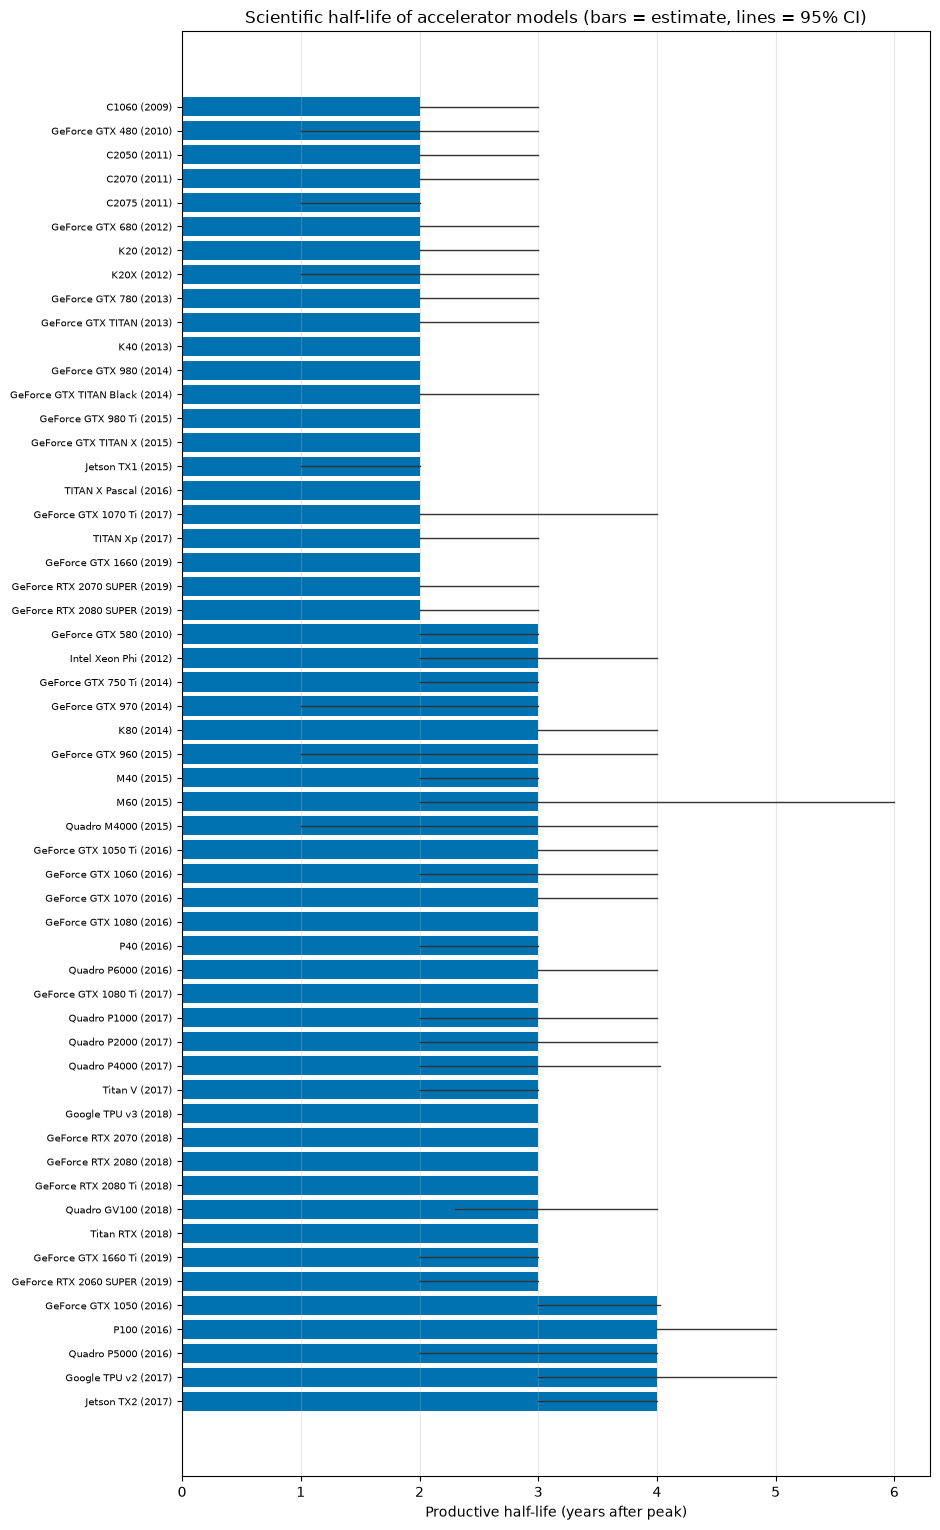

shape: (96, 7)
┌───────────────────┬──────────────┬───────────┬───────────────┬───────────┬──────────┬────────────┐
│ display           ┆ release_year ┆ peak_year ┆ years_to_peak ┆ half_life ┆ censored ┆ peak_share │
│ ---               ┆ ---          ┆ ---       ┆ ---           ┆ ---       ┆ ---      ┆ ---        │
│ str               ┆ i64          ┆ i64       ┆ i64           ┆ i64       ┆ bool     ┆ f64        │
╞═══════════════════╪══════════════╪═══════════╪═══════════════╪═══════════╪══════════╪════════════╡
│ NVIDIA C1060      ┆ 2009         ┆ 2010      ┆ 1             ┆ 2         ┆ false    ┆ 0.1664     │
│ NVIDIA GeForce    ┆ 2010         ┆ 2012      ┆ 2             ┆ 2         ┆ false    ┆ 0.1152     │
│ GTX 480           ┆              ┆           ┆               ┆           ┆          ┆            │
│ NVIDIA GeForce    ┆ 2010         ┆ 2012      ┆ 2             ┆ 3         ┆ false    ┆ 0.1031     │
│ GTX 580           ┆              ┆           ┆               ┆           ┆

In [19]:
per_year = pm.group_by('year').agg(accel_papers=pl.col('corpusid').n_unique())
shares = (pm.group_by('canonical_model', 'year').agg(k=pl.col('corpusid').n_unique())
          .join(per_year, on='year')
          .with_columns(share=pl.col('k') / pl.col('accel_papers')))

def smooth(v: np.ndarray, w: int = SMOOTH) -> np.ndarray:
    if w <= 1 or v.size < w:
        return v
    ker = np.ones(w) / w
    return np.convolve(v, ker, mode='same')

def half_life(years: np.ndarray, sh: np.ndarray, persist: int = 2):
    """-> (peak_year, peak_share, half_life or None if censored)"""
    sm = smooth(sh)
    pi = int(np.argmax(sm))
    peak, py = sm[pi], years[pi]
    thr = peak / 2
    below = 0
    for j in range(pi + 1, len(years)):
        below = below + 1 if sm[j] <= thr else 0
        if below >= persist:
            return py, peak, int(years[j - persist + 1] - py)
    return py, peak, None

rows = []
for mid in elig['canonical_model']:
    s = shares.filter(pl.col('canonical_model') == mid).sort('year')
    if s.height < 4:
        continue
    yy = s['year'].to_numpy(); vv = s['share'].to_numpy().astype(float)
    py, peak, hl = half_life(yy, vv)
    boots = []
    rng = np.random.default_rng(0)
    for _ in range(BOOTSTRAP):
        jitter = rng.poisson(np.maximum(s['k'].to_numpy(), 0)).astype(float)
        tot = s['accel_papers'].to_numpy().astype(float)
        _, _, h = half_life(yy, np.divide(jitter, tot, out=np.zeros_like(tot), where=tot > 0))
        if h is not None:
            boots.append(h)
    d = meta.filter(pl.col('canonical_model') == mid)
    rows.append({'canonical_model': mid, 'display': d['display'][0],
                 'release_year': d['release_year'][0], 'segment': d['segment'][0],
                 'peak_year': int(py), 'peak_share': float(peak),
                 'half_life': hl, 'censored': hl is None,
                 'hl_lo': float(np.percentile(boots, 2.5)) if boots else None,
                 'hl_hi': float(np.percentile(boots, 97.5)) if boots else None,
                 'years_to_peak': int(py - d['release_year'][0]) if d['release_year'][0] else None})
hl = pl.DataFrame(rows).sort('release_year', 'display')
obs = hl.filter(~pl.col('censored')).sort('half_life')
print(f'{hl.height} models: {obs.height} with observed half-life, '
      f'{hl.height - obs.height} right-censored')
print('median observed half-life:', obs['half_life'].median(), 'years')

fig, ax = plt.subplots(figsize=(9.5, max(4, 0.28 * obs.height)))
yy = np.arange(obs.height)
ax.barh(yy, obs['half_life'], color='#0072B2')
for i, (lo, hi, h) in enumerate(zip(obs['hl_lo'], obs['hl_hi'], obs['half_life'])):
    if lo is not None and hi is not None:
        ax.plot([lo, hi], [i, i], color='#333333', lw=1)
ax.set_yticks(yy)
ax.set_yticklabels([f"{d.replace('NVIDIA ','')} ({r})" for d, r in
                    zip(obs['display'], obs['release_year'])], fontsize=7)
ax.invert_yaxis()
ax.set(xlabel='Productive half-life (years after peak)',
       title='Scientific half-life of accelerator models (bars = estimate, lines = 95% CI)')
ax.grid(alpha=0.3, axis='x'); plt.tight_layout(); plt.show()
with pl.Config(tbl_rows=40, fmt_str_lengths=34):
    print(hl.select('display', 'release_year', 'peak_year', 'years_to_peak',
                    'half_life', 'censored',
                    pl.col('peak_share').round(4)).sort('release_year'))

### Half-life diagnostics

The plan requires a diagnostic panel per reported half-life — raw share,
smoothed curve, peak, half-peak threshold, crossing year — so an automated
estimate cannot silently be wrong.

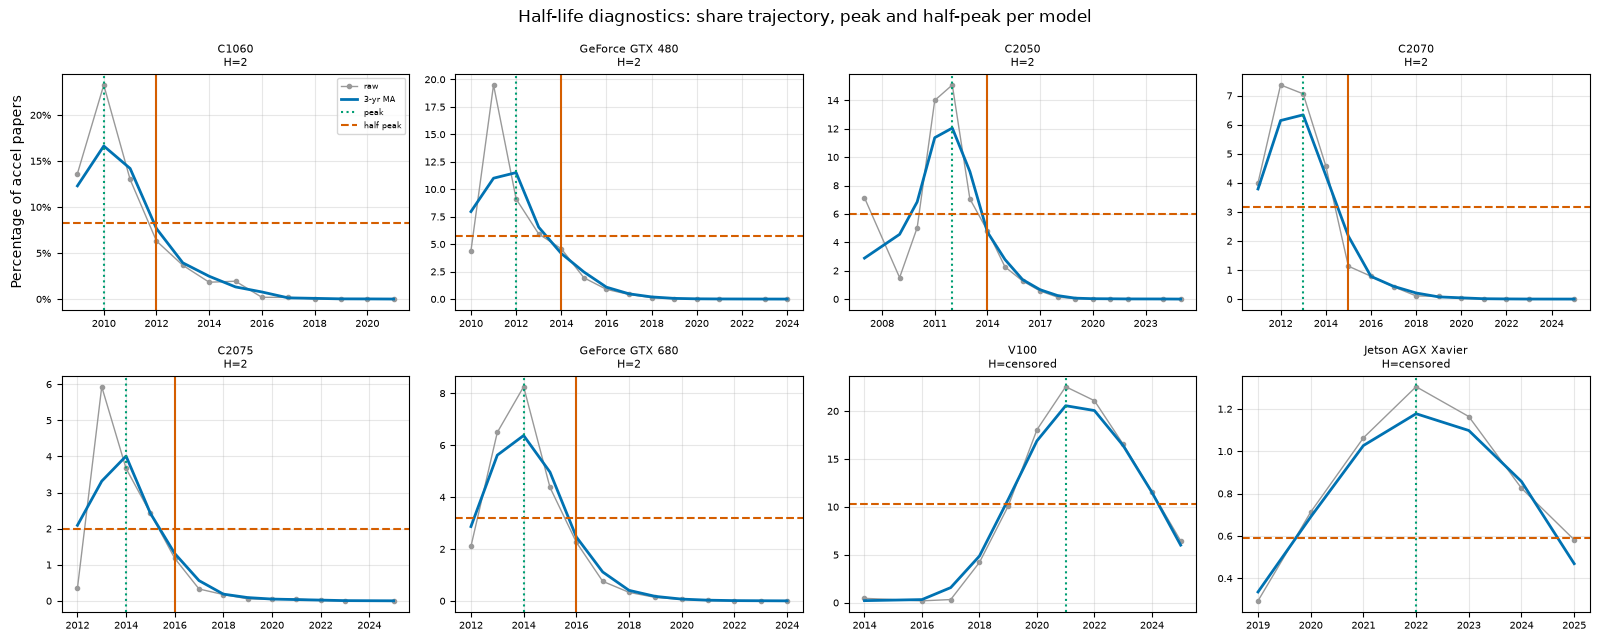

In [20]:
show = obs.head(6)['canonical_model'].to_list() + \
       hl.filter(pl.col('censored')).head(2)['canonical_model'].to_list()
fig, axes = plt.subplots(2, 4, figsize=(16, 6.5))
for ax, mid in zip(axes.ravel(), show):
    s = shares.filter(pl.col('canonical_model') == mid).sort('year')
    yy = s['year'].to_numpy(); vv = s['share'].to_numpy().astype(float)
    r = hl.filter(pl.col('canonical_model') == mid).row(0, named=True)
    ax.plot(yy, 100 * vv, marker='.', color='#999999', lw=1, label='raw')
    ax.plot(yy, 100 * smooth(vv), color='#0072B2', lw=2, label=f'{SMOOTH}-yr MA')
    ax.axvline(r['peak_year'], color='#009E73', ls=':', label='peak')
    ax.axhline(100 * r['peak_share'] / 2, color='#D55E00', ls='--', label='half peak')
    if r['half_life'] is not None:
        ax.axvline(r['peak_year'] + r['half_life'], color='#D55E00', lw=1.5)
    ax.set_title(f"{r['display'].replace('NVIDIA ','')}\n"
                 f"H={'censored' if r['censored'] else r['half_life']}", fontsize=8)
    ax.tick_params(labelsize=7); ax.grid(alpha=0.3)
axes[0, 0].set_ylabel('Percentage of accel papers'); axes[0, 0].legend(fontsize=6)
fig.suptitle('Half-life diagnostics: share trajectory, peak and half-peak per model')
plt.tight_layout(); plt.show()

## 6.3 Adoption lag by generation

Months from commercial release to first scientific mention, and to the 10th and
100th supporting paper. Plotted against release year: a downward slope means
science is absorbing each new generation faster than the last.

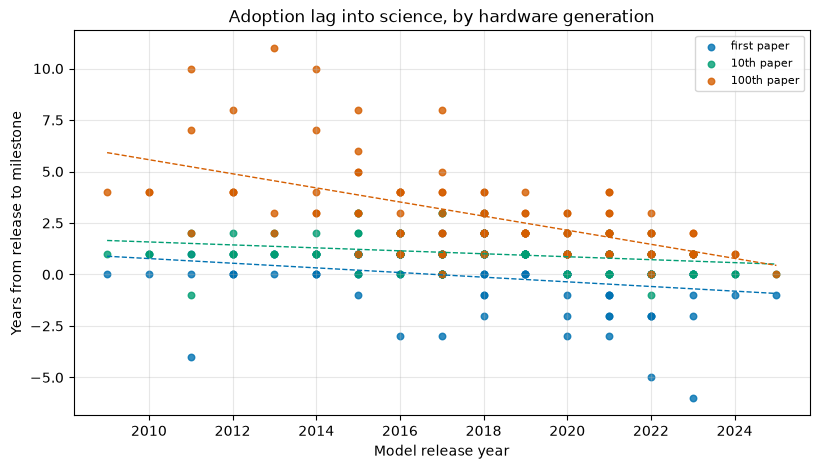

shape: (104, 6)
┌────────────────────────────────┬──────────────┬─────────────┬───────────┬────────┬─────────┐
│ display                        ┆ release_year ┆ segment     ┆ lag_first ┆ lag_10 ┆ lag_100 │
│ ---                            ┆ ---          ┆ ---         ┆ ---       ┆ ---    ┆ ---     │
│ str                            ┆ i64          ┆ str         ┆ i64       ┆ i64    ┆ i64     │
╞════════════════════════════════╪══════════════╪═════════════╪═══════════╪════════╪═════════╡
│ NVIDIA C1060                   ┆ 2009         ┆ datacenter  ┆ 0         ┆ 1      ┆ 4       │
│ NVIDIA GeForce GTX 580         ┆ 2010         ┆ consumer    ┆ 1         ┆ 1      ┆ 4       │
│ NVIDIA GeForce GTX 480         ┆ 2010         ┆ consumer    ┆ 0         ┆ 1      ┆ 4       │
│ NVIDIA C2050                   ┆ 2011         ┆ datacenter  ┆ -4        ┆ -1     ┆ 2       │
│ NVIDIA C2070                   ┆ 2011         ┆ datacenter  ┆ 0         ┆ 1      ┆ 7       │
│ NVIDIA C2075                   ┆

In [21]:
rows = []
for mid in elig['canonical_model']:
    d = meta.filter(pl.col('canonical_model') == mid).row(0, named=True)
    if not d['release_year']:
        continue
    s = (pm.filter(pl.col('canonical_model') == mid)
         .group_by('year').agg(k=pl.col('corpusid').n_unique()).sort('year'))
    if not s.height:
        continue
    cum, milestones = 0, {}
    for y, k in zip(s['year'], s['k']):
        cum += k
        for thr in (1, 10, 100):
            if thr not in milestones and cum >= thr:
                milestones[thr] = y - d['release_year']
    rows.append({'display': d['display'], 'release_year': d['release_year'],
                 'segment': d['segment'],
                 'lag_first': milestones.get(1), 'lag_10': milestones.get(10),
                 'lag_100': milestones.get(100)})
lag = pl.DataFrame(rows).filter(pl.col('lag_first').is_not_null())
fig, ax = plt.subplots(figsize=(9.5, 5))
for lbl, col, c in [('first paper', 'lag_first', '#0072B2'),
                    ('10th paper', 'lag_10', '#009E73'),
                    ('100th paper', 'lag_100', '#D55E00')]:
    s = lag.filter(pl.col(col).is_not_null())
    ax.scatter(s['release_year'], s[col], s=22, label=lbl, color=c, alpha=0.8)
    if s.height > 3:
        z = np.polyfit(s['release_year'].to_numpy(), s[col].to_numpy().astype(float), 1)
        xs = np.array([s['release_year'].min(), s['release_year'].max()])
        ax.plot(xs, np.polyval(z, xs), color=c, ls='--', lw=1)
ax.set(xlabel='Model release year', ylabel='Years from release to milestone',
       title='Adoption lag into science, by hardware generation')
ax.legend(fontsize=8); ax.grid(alpha=0.3); plt.show()
with pl.Config(tbl_rows=30, fmt_str_lengths=34):
    print(lag.sort('release_year'))

### Validity check: pre-release mentions

A paper cannot legitimately use a chip released after it was published, so the
pre-release rate is a direct measurement-validity probe (the plan requires
flagging, not silently dropping, these).

Audited on the full run: **~0.08% of used-model observations are pre-release**
(102 at -1 year, 21 at -2, 11 at -3 or earlier). Identified causes: S2ORC year
metadata errors (one paper dated **1970** — a Unix-epoch default), preprint /
version date mismatches, and a handful of registry release dates that are a
year off. Negligible for aggregate trends, but they distort `lag_first` in the
adoption-lag table above, which is why lags there should be read with the
pre-release rows excluded.

In [22]:
# pre-release audit + clipped adoption lags
pmv = pm.filter(pl.col('release_year').is_not_null() & (pl.col('year') >= 1990))
pmv = pmv.with_columns(gap=pl.col('year') - pl.col('release_year'))
pre = pmv.filter(pl.col('gap') < 0)
print(f'used-model observations (year >= 1990): {pmv.height:,}')
print(f'pre-release: {pre.height:,} ({100*pre.height/pmv.height:.3f}%)')
print(pre.group_by('gap').len().sort('gap'))
print('\nmost affected models:')
print(pre.group_by('display').len().sort('len', descending=True).head(8))
bad_year = pm.filter(pl.col('year') < 1990)
print(f'\npapers with implausible year (<1990), excluded here: {bad_year.height}')

lag_clean = (lag.with_columns(
    pl.col('lag_first').clip(0, None), pl.col('lag_10').clip(0, None),
    pl.col('lag_100').clip(0, None)))
print('\nadoption lag (pre-release clipped to 0), medians by release era:')
print(lag_clean.with_columns(
        era=pl.when(pl.col('release_year') < 2015).then(pl.lit('pre-2015'))
        .when(pl.col('release_year') < 2020).then(pl.lit('2015-2019'))
        .otherwise(pl.lit('2020+')))
      .group_by('era').agg(n=pl.len(), med_first=pl.col('lag_first').median(),
                           med_10=pl.col('lag_10').median(),
                           med_100=pl.col('lag_100').median()).sort('era'))

used-model observations (year >= 1990): 197,376
pre-release: 99 (0.050%)
shape: (6, 2)
┌─────┬─────┐
│ gap ┆ len │
│ --- ┆ --- │
│ i64 ┆ u32 │
╞═════╪═════╡
│ -6  ┆ 1   │
│ -5  ┆ 1   │
│ -4  ┆ 1   │
│ -3  ┆ 5   │
│ -2  ┆ 16  │
│ -1  ┆ 75  │
└─────┴─────┘

most affected models:
shape: (8, 2)
┌────────────────────────────┬─────┐
│ display                    ┆ len │
│ ---                        ┆ --- │
│ str                        ┆ u32 │
╞════════════════════════════╪═════╡
│ NVIDIA GeForce RTX 3090 Ti ┆ 32  │
│ NVIDIA C2050               ┆ 10  │
│ NVIDIA A100                ┆ 5   │
│ Apple M2                   ┆ 4   │
│ NVIDIA V100                ┆ 4   │
│ NVIDIA GeForce RTX 5090    ┆ 4   │
│ Apple M1                   ┆ 4   │
│ Apple M3                   ┆ 3   │
└────────────────────────────┴─────┘

papers with implausible year (<1990), excluded here: 0

adoption lag (pre-release clipped to 0), medians by release era:
shape: (3, 5)
┌───────────┬─────┬───────────┬────────┬─────────┐
│ e

## 6.4 Citation support

Forward citations (`i_3`, set by the `CITE_WINDOW` knob) attributed to each model, on
the same counting rule as 6.1. Restricted to papers published <= `CITE_CUTOFF`, so
that every paper in the numerator has had a full `CITE_WINDOW` years to accumulate
citations — without that restriction recent chips would be penalised for youth, which
is the single most important restriction in this section.

A shorter citation window is the right trade here: it admits several more years of
papers (and therefore the newer accelerators) at the cost of measuring less of each
paper's eventual impact.

Volume and intensity answer different questions. A chip can support a large citation
total simply by supporting many papers; mean citations per supporting paper asks
whether the work done on it landed harder.


103,833 paper-model obs with a complete 3-yr citation window


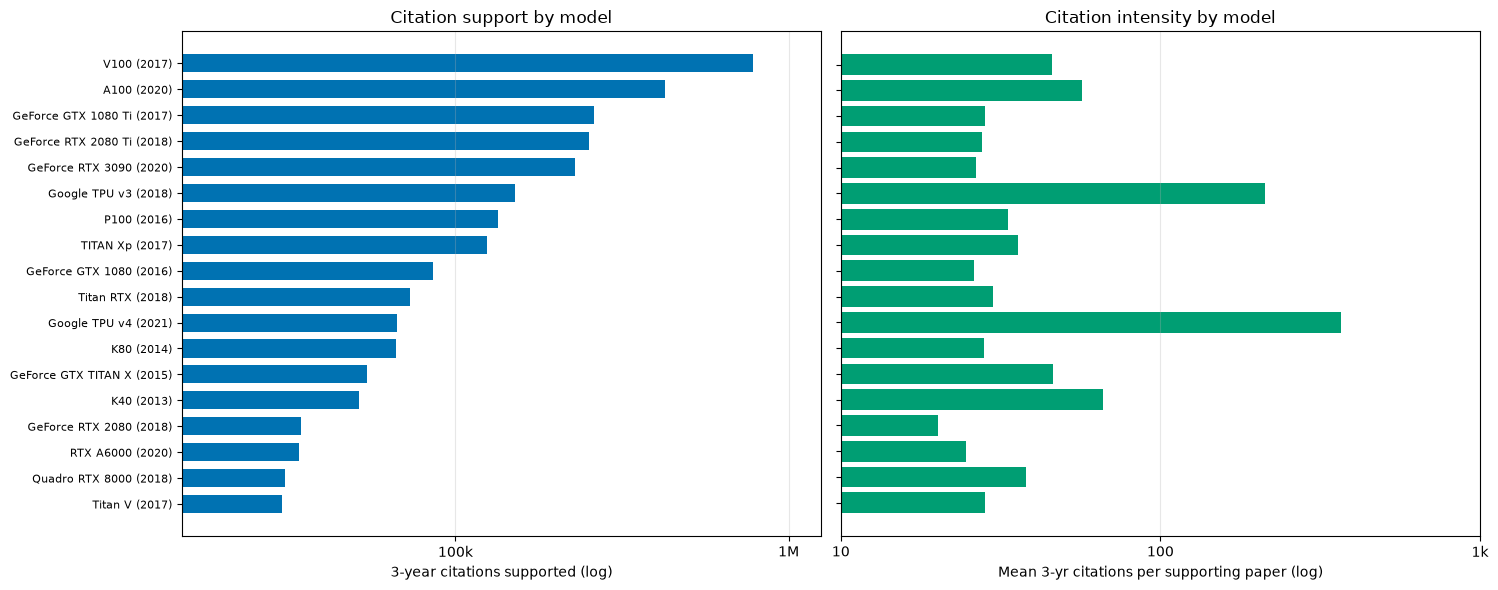

shape: (25, 6)
┌────────────────────────────┬──────────────┬────────┬────────┬────────────┬──────────────┐
│ display                    ┆ release_year ┆ papers ┆ cites  ┆ cites_mean ┆ cites_median │
│ ---                        ┆ ---          ┆ ---    ┆ ---    ┆ ---        ┆ ---          │
│ str                        ┆ i32          ┆ u32    ┆ i64    ┆ f64        ┆ f64          │
╞════════════════════════════╪══════════════╪════════╪════════╪════════════╪══════════════╡
│ NVIDIA V100                ┆ 2017         ┆ 17080  ┆ 781835 ┆ 45.8       ┆ 12.0         │
│ NVIDIA A100                ┆ 2020         ┆ 7521   ┆ 426411 ┆ 56.7       ┆ 12.0         │
│ NVIDIA GeForce GTX 1080 Ti ┆ 2017         ┆ 9212   ┆ 260877 ┆ 28.3       ┆ 10.0         │
│ NVIDIA GeForce RTX 2080 Ti ┆ 2018         ┆ 9135   ┆ 252059 ┆ 27.6       ┆ 10.0         │
│ NVIDIA GeForce RTX 3090    ┆ 2020         ┆ 8677   ┆ 229169 ┆ 26.4       ┆ 9.0          │
│ Google TPU v3              ┆ 2018         ┆ 707    ┆ 150431 ┆ 2

In [23]:
cw = pm.filter(pl.col('cite_window_complete') & pl.col('has_outcomes'))
print(f'{cw.height:,} paper-model obs with a complete {CITE_WINDOW}-yr citation window')
cs = (cw.group_by('canonical_model', 'display', 'release_year')
      .agg(papers=pl.len(),
           cites=pl.col('citations').sum(),
           cites_mean=pl.col('citations').mean(),
           cites_median=pl.col('citations').median())
      .filter(pl.col('papers') >= 30).sort('cites', descending=True))

top = cs.head(18)
fig, axes = plt.subplots(1, 2, figsize=(15, 6))
y = np.arange(top.height)
axes[0].barh(y, top['cites'], 0.7, color='#0072B2')
axes[0].set_yticks(y)
axes[0].set_yticklabels([f"{d.replace('NVIDIA ', '')} ({r})" for d, r in
                         zip(top['display'], top['release_year'])], fontsize=8)
axes[0].invert_yaxis(); axes[0].grid(alpha=0.3, axis='x')
axes[0].set(xlabel=f'{CITE_WINDOW}-year citations supported (log)',
            title='Citation support by model')
axes[1].barh(y, top['cites_mean'], color='#009E73')
axes[1].set_yticks(y); axes[1].set_yticklabels([]); axes[1].invert_yaxis()
axes[1].set(xlabel=f'Mean {CITE_WINDOW}-yr citations per supporting paper (log)',
            title='Citation intensity by model')
axes[1].grid(alpha=0.3, axis='x')
# log x on a bar chart: bars run from the left spine, so the limits have to be set
# explicitly or the smallest bar collapses into it and the value labels overflow
for ax, col in ((axes[0], 'cites'), (axes[1], 'cites_mean')):
    ax.set_xscale('log')
    ax.set_xlim(top[col].min() / 2, top[col].max() * 1.6)
    # plain '{v:g}' turns citation totals into '1e+06'
    ax.xaxis.set_major_formatter(
        lambda v, _: f'{v*1e-6:g}M' if v >= 1e6 else
        (f'{v*1e-3:g}k' if v >= 1e3 else f'{v:g}'))
plt.tight_layout(); plt.show()
with pl.Config(tbl_rows=25, fmt_str_lengths=34):
    print(cs.select('display', 'release_year', 'papers', 'cites',
                    pl.col('cites_mean').round(1),
                    pl.col('cites_median').round(1)).head(25))

### Ranking stability: papers vs citations

If a model's citation rank far exceeds its paper rank, a handful of famous
papers is doing the work. Comparing the three rankings is the honest way to
present "device productivity" without implying causality.

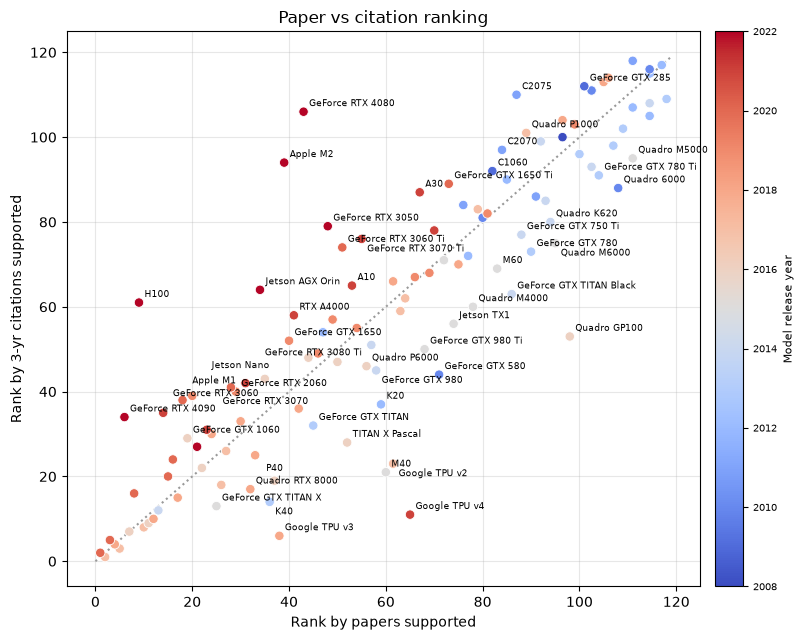

Spearman-style rank correlations (pairwise complete):
  rank_papers vs rank_cites: 0.872  (n=118)
  rank_papers vs rank_intensity: 0.383  (n=118)
  rank_cites vs rank_intensity: 0.682  (n=118)


In [26]:
# cs.papers counts only complete-window papers, so the all-year count is aliased
rk = (cs.join(sup.select('canonical_model', papers_all='papers'),
              on='canonical_model', how='left')
      .with_columns(rank_papers=pl.col('papers_all').rank(descending=True),
                    rank_cites=pl.col('cites').rank(descending=True),
                    rank_intensity=pl.col('cites_mean').rank(descending=True)))
fig, ax = plt.subplots(figsize=(8.5, 6.5))
lim = max(rk['rank_papers'].max(), rk['rank_cites'].max()) + 1
ax.plot([0, lim], [0, lim], ls=':', color='#999999', zorder=1)
# release year is a magnitude, so one hue light->dark; the low end is truncated off
# white so the oldest models stay visible against the panel
blues = plt.get_cmap('coolwarm')
ry = rk.filter(pl.col('release_year').is_not_null())
sc = ax.scatter(ry['rank_papers'], ry['rank_cites'], s=46, c=ry['release_year'],
                cmap=blues, edgecolors='white', linewidths=0.6, zorder=3)
unknown = rk.filter(pl.col('release_year').is_null())
if unknown.height:
    ax.scatter(unknown['rank_papers'], unknown['rank_cites'], s=46, color='#BBBBBB',
               edgecolors='white', linewidths=0.6, zorder=3, label='release year unknown')
    ax.legend(fontsize=7, loc='lower right')
cb = fig.colorbar(sc, ax=ax, pad=0.02)
cb.set_label('Model release year', fontsize=8)
cb.ax.tick_params(labelsize=7)
for r in rk.iter_rows(named=True):
    if abs(r['rank_papers'] - r['rank_cites']) >= 10:
        ax.annotate(r['display'].replace('NVIDIA ', ''),
                    (r['rank_papers'], r['rank_cites']), fontsize=6.5,
                    xytext=(4, 4), textcoords='offset points')
spread_labels(ax)      # nudge apart only where labels genuinely collide
ax.set(xlabel='Rank by papers supported',
       ylabel=f'Rank by {CITE_WINDOW}-yr citations supported',
       title='Paper vs citation ranking')
ax.grid(alpha=0.3); plt.tight_layout(); plt.show()
# drop pairwise: a model missing one measure should not nan out the correlation
print('Spearman-style rank correlations (pairwise complete):')
for a, b in [('rank_papers', 'rank_cites'), ('rank_papers', 'rank_intensity'),
             ('rank_cites', 'rank_intensity')]:
    d = rk.select(a, b).drop_nulls()
    r = np.corrcoef(d[a].to_numpy(), d[b].to_numpy())[0, 1] if d.height > 2 else float('nan')
    print(f'  {a} vs {b}: {r:.3f}  (n={d.height})')